In [69]:
import math
from concurrent.futures import ProcessPoolExecutor, as_completed
from itertools import product

import numpy as np
import pandas as pd
import plotnine as p9
import pyvinecopulib as pv
from IPython import get_ipython
from tqdm import tqdm

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
# Sample a single pair copula from the itau set with tau in [lower, upper]
def sample_pair_copula(lower=-0.9, upper=0.9, rng=None) -> pv.Bicop:
  # set seed and create random number generator
  if rng is None:
    seed = np.random.randint(0, 2**32 - 1)
    rng = np.random.default_rng(seed)

  # sample family and tau
  family = rng.choice(pv.itau)
  tau = rng.uniform(lower, upper)

  # create copula and set parameters
  copula = pv.Bicop(family)
  if family == pv.BicopFamily.student:
    rho = 2 * np.arcsin(tau) / np.pi
    nu = rng.uniform(3, 10)
    parameters = np.array([[rho], [nu]])
  else:
    parameters = copula.tau_to_parameters(tau)
  if family in [pv.BicopFamily.clayton, pv.BicopFamily.gumbel] and tau < 0:
    # rotate copula by 90 or 180 degrees if tau is negative
    rotation = rng.choice([90, 180])
    copula.rotation = rotation
  copula.parameters = parameters
  return copula


# Sample a vine copula with dim dimensions and trunc_lvl truncation levels
def sample_vine_copula(
  dim=3, trunc_lvl=np.inf, lower=-0.9, upper=0.9, decreasing=True, seed=12
) -> pv.Vinecop:
  # set seed and create random number generator
  rng = np.random.default_rng(seed)

  # Random structure
  structure = pv.RVineStructure.simulate(dim, seeds=[seed])

  # Random pair copulas
  pair_copulas = []
  trunc_lvl = min(dim, trunc_lvl)
  for i in range(trunc_lvl - 1):
    if decreasing:
      rate = 1 / math.sqrt(i + 1)
    else:
      rate = 1.0
    pair_copulas.append([])
    for J in range(dim - i - 1):
      pair_copula = sample_pair_copula(lower * rate, upper * rate, rng)
      pair_copulas[i].append(pair_copula)

  cop = pv.Vinecop.from_structure(
    structure=structure, pair_copulas=pair_copulas
  )

  return cop


def get_controls(trunc_lvl):
  return pv.FitControlsVinecop(
    family_set=[pv.BicopFamily.tll], trunc_lvl=trunc_lvl, num_threads=3
  )

In [71]:
from vinesforest.vines_forest import VinesForest

# Example with a 3-dimensional vine copula
seed = 12
dim = 3
n_samples = 500
n_vines = 100
decreasing = True
algorithm = "jck"
cop = sample_vine_copula(dim=dim, decreasing=decreasing, seed=seed)
data = cop.simulate(n_samples, seeds=[seed])
controls = get_controls(trunc_lvl=dim)

# Fit with Dissmann and forest
fitted_dissmann = pv.Vinecop.from_data(data, controls=controls)
fitted_forest = VinesForest(n_vines, algorithm, controls)
fitted_forest.fit(data)

# Compare log-likelihood of the fitted vine and the fitted forest
loglik_dissmann = fitted_dissmann.loglik()
loglik_forest = fitted_forest.loglik()

# Dissman vs max forest
print(loglik_dissmann)
print(loglik_forest.max())

# Proportion of the forest that is better than the dissman
print(np.mean(loglik_forest > loglik_dissmann))

846.6034089827685
851.9052982059546
0.72


In [72]:
import time


# Evaluate the KL divergence using Monte Carlo integration
def kl_divergence(
  cop_fitted: pv.Vinecop, cop_true: pv.Vinecop, n_mc_samples=1000, seed=42
) -> float:
  # Set the random seed
  rng = np.random.default_rng(seed)
  seeds = [int(rng.integers(0, 2**31 - 1)) for _ in range(10)]

  # Sample data from the true copula
  data = cop_true.simulate(n_mc_samples, seeds=seeds)

  # Compute the density of the true copula
  density_true = cop_true.pdf(data)

  # Compute the density of the true copula
  density_fitted = cop_fitted.pdf(data)

  # Compute the KL divergence
  kl_div = np.mean(np.log(density_true / density_fitted))

  return float(kl_div)


def compare_dissmann_forest(
  dim: int,
  n_samples: int,
  n_vines: int,
  algorithm: str,
  decreasing: bool,
  seed: int,
):
  # Set the random seed
  rng = np.random.default_rng(seed)
  seeds = [int(rng.integers(0, 2**31 - 1)) for _ in range(10)]

  cop_true = sample_vine_copula(dim=dim, decreasing=decreasing, seed=seed)
  data = cop_true.simulate(n_samples, seeds=seeds)
  controls = get_controls(dim)

  tic = time.time()
  cop_dissmann = pv.Vinecop.from_data(data, controls=controls)
  toc = time.time()
  loglik_dissmann = cop_dissmann.loglik()
  kl_dissmann = kl_divergence(cop_dissmann, cop_true, seed=seed)
  time_dissmann = toc - tic

  tic = time.time()
  cops_forest = VinesForest(n_vines, algorithm=algorithm, controls=controls)
  cops_forest.fit(data, seed=seed)
  toc = time.time()
  time_forest = toc - tic
  logliks_forest = cops_forest.loglik()
  prop_better = float(np.mean(logliks_forest > loglik_dissmann))
  best_forest_idx = logliks_forest.argmax()

  cop_forest = cops_forest.vines[best_forest_idx][1]
  kl_forest = kl_divergence(cop_forest, cop_true, seed=seed)
  loglik_forest = float(logliks_forest[best_forest_idx])

  return {
    "dim": dim,
    "n_samples": n_samples,
    "n_vines": n_vines,
    "decreasing": decreasing,
    "algorithm": algorithm,
    "seed": seed,
    "loglik_dissmann": loglik_dissmann,
    "time_dissmann": time_dissmann,
    "kl_dissmann": kl_dissmann,
    "loglik_forest": loglik_forest,
    "time_forest": time_forest,
    "kl_forest": kl_forest,
    "prop_better": prop_better,
  }


compare_dissmann_forest(
  dim=9,
  n_samples=1000,
  n_vines=100,
  decreasing=True,
  seed=42,
  algorithm="jck",
)

{'dim': 9,
 'n_samples': 1000,
 'n_vines': 100,
 'decreasing': True,
 'algorithm': 'jck',
 'seed': 42,
 'loglik_dissmann': 6717.1833667258425,
 'time_dissmann': 0.24900102615356445,
 'kl_dissmann': 0.08606126855180735,
 'loglik_forest': 6615.504457875571,
 'time_forest': 27.385673761367798,
 'kl_forest': 0.18774017740207968,
 'prop_better': 0.0}

In [73]:
# Let's try to generalize for several dimensions, sizes and seeds
dims = [5, 10, 20]
# n_samples = [50, 100, 500, 1000, 5000]
n_samples = [100, 1000]
n_vines = [1, 10, 100, 500]
decreasings = [True, False]
algorithm = ["jck", "wilson"]

seeds = list(range(20))


# Define the parameter combinations
param_combinations = list(
  product(dims, n_samples, n_vines, decreasings, algorithm)
)

print(len(param_combinations))

96


In [74]:
# Function to wrap compare_vines for map usage
def run_simulation(seed):
  results = []
  for dim, n_samples, n_vines, decreasing, algorithm in param_combinations:
    result = compare_dissmann_forest(
      dim=dim,
      n_samples=n_samples,
      n_vines=n_vines,
      decreasing=decreasing,
      algorithm=algorithm,
      seed=seed,
    )
    results.append(result)
  return results


# Execute in parallel with a progress bar
results = []
with ProcessPoolExecutor() as executor:
  # Submit all tasks and wrap them in a progress bar
  futures = {executor.submit(run_simulation, seed): seed for seed in seeds}

  # Display progress bar as tasks complete
  for future in tqdm(
    as_completed(futures), total=len(futures), desc="Processing simulations"
  ):
    seed = futures[future]
    try:
      result = future.result()
      results.append(result)
    except Exception as e:
      print(f"Error with seed {seed}: {e}")

#   # Convert results to a DataFrame
# df = pd.DataFrame(results)

# df["forest_over_dissmann"] = df["loglik_forest"] / df["loglik_dissmann"]

Processing simulations:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: divide by zero encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: overflow encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: divide by zero encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: overflow encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: divide by zero encountered in log
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: divide by zero encountered in divide
/home/tvatter/Dropbox/github/vinesforets/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in reduce
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: overflow encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: divide by zero encountered in divide
/tmp/ipykernel_79490/2733364644.py:22: RuntimeWarning: overflow en

In [80]:
df = pd.concat([pd.DataFrame(result) for result in results])
df["forest_over_dissmann"] = df["loglik_forest"] / df["loglik_dissmann"]
df.to_csv("data/results.csv", index=False)

In [ ]:
# # Function to wrap compare_vines for map usage
# def run_simulation(params):
#   dim, n_samples, n_vines, decreasing, algorithm, seed = params
#   return compare_dissmann_forest(
#     dim=dim,
#     n_samples=n_samples,
#     n_vines=n_vines,
#     decreasing=decreasing,
#     algorithm=algorithm,
#     seed=seed,
#   )


# # Execute in parallel with a progress bar
# results = []
# with ProcessPoolExecutor() as executor:
#   # Submit all tasks and wrap them in a progress bar
#   futures = {
#     executor.submit(run_simulation, params): params
#     for params in param_combinations
#   }

#   # Display progress bar as tasks complete
#   for future in tqdm(
#     as_completed(futures), total=len(futures), desc="Processing simulations"
#   ):
#     params = futures[future]
#     try:
#       result = future.result()
#       results.append(result)
#     except Exception as e:
#       print(f"Error with parameters {params}: {e}")

#   # Convert results to a DataFrame
# df = pd.DataFrame(results)

# df["forest_over_dissmann"] = df["loglik_forest"] / df["loglik_dissmann"]

Processing simulations: 100%|██████████| 1200/1200 [48:36<00:00,  2.43s/it]   


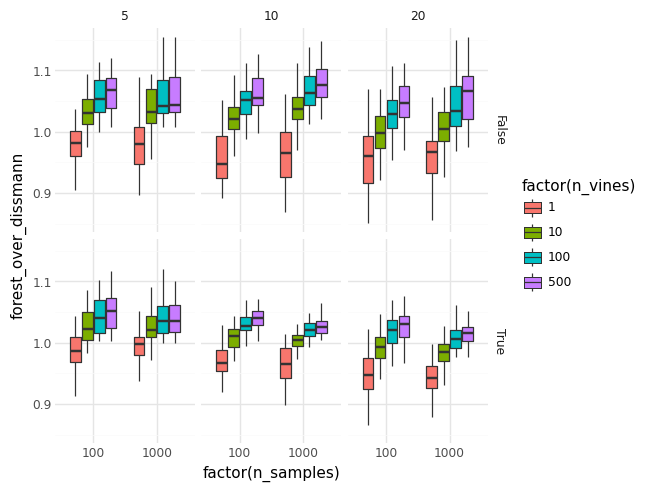

In [102]:
# df.to_csv("data/results.csv", index=False)
# df = pd.read_csv("data/results.csv")

# Plot the average ratio of the max forest log-likelihood to the dissman
p = (
  p9.ggplot(
    df,
    p9.aes(
      x="factor(n_samples)",
      y="forest_over_dissmann",
      fill="factor(n_vines)",
    ),
  )
  + p9.geom_boxplot(outlier_shape="")
  + p9.facet_grid(cols="dim", rows="decreasing")
  + p9.theme_minimal()
)
p.show()

In [104]:
df_long = df[
  [
    "dim",
    "seed",
    "decreasing",
    "algorithm",
    "n_samples",
    "n_vines",
    "kl_forest",
    "kl_dissmann",
  ]
].melt(
  id_vars=["seed", "dim", "n_samples", "n_vines", "decreasing", "algorithm"],
  value_name="kl",
  var_name="method",
)
df_long.loc[df_long["method"] == "kl_dissmann", "n_vines"] = None
df_long["method"] = (
  df_long["method"].str.replace("kl_", " ")
  + " "
  + df_long["n_vines"].astype("str")
).str.replace(" nan", "")
df_long

,seed,dim,n_samples,n_vines,decreasing,algorithm,method,kl
0,10,5,100,1.0,True,jck,forest 1.0,0.897
1,10,5,100,1.0,True,wilson,forest 1.0,0.879
2,10,5,100,1.0,False,jck,forest 1.0,2.844
3,10,5,100,1.0,False,wilson,forest 1.0,2.690
4,10,5,100,10.0,True,jck,forest 10.0,0.877
...,...,...,...,...,...,...,...,...
3835,4,20,1000,NaN,False,wilson,dissmann,48.574
3836,4,20,1000,NaN,True,jck,dissmann,1.538
3837,4,20,1000,NaN,True,wilson,dissmann,1.538
3838,4,20,1000,NaN,False,jck,dissmann,48.574


/home/tvatter/Dropbox/github/vinesforets/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/home/tvatter/Dropbox/github/vinesforets/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 585 rows containing non-finite values.


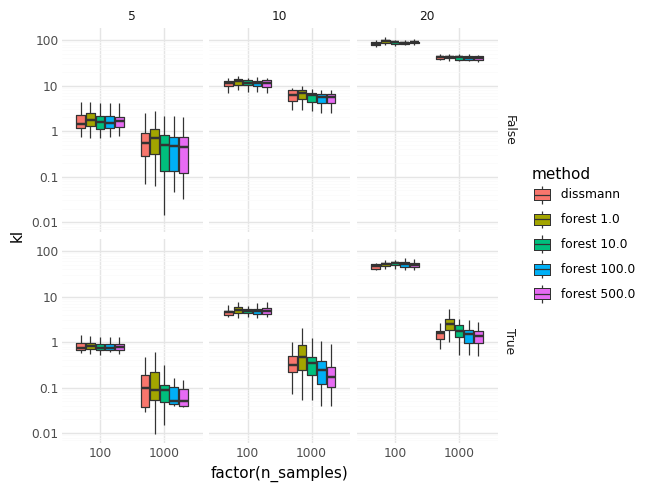

In [ ]:
df_long = df[
  [
    "dim",
    "seed",
    "decreasing",
    "algorithm",
    "n_samples",
    "n_vines",
    "kl_forest",
    "kl_dissmann",
  ]
].melt(
  id_vars=["seed", "dim", "n_samples", "n_vines", "decreasing", "algorithm"],
  value_name="kl",
  var_name="method",
)
df_long.loc[df_long["method"] == "kl_dissmann", "n_vines"] = None
df_long["method"] = (
  df_long["method"].str.replace("kl_", " ")
  + " "
  + df_long["n_vines"].astype("str")
).str.replace(" nan", "")

# Plot the average KL divergence of the max forest to the true copula
p = (
  p9.ggplot(
    df_long,
    p9.aes(x="factor(n_samples)", y="kl", fill="method"),
  )
  + p9.geom_boxplot(outlier_shape="")
  + p9.scale_y_log10()
  + p9.facet_grid("decreasing", "dim")
  + p9.theme_minimal()
)
p.show()

In [92]:
(
  df_long.dropna(subset=["kl"])
  .drop(columns=["seed", "n_vines"])
  .groupby(["dim", "decreasing", "n_samples", "method"])["kl"]
  .mean()
)

dim  decreasing  n_samples  method      
5    False       100        dissmann         1.803
                            forest 1.0       1.975
                            forest 10.0      1.792
                            forest 100.0     1.768
                            forest 500.0     1.806
                 1000       dissmann         0.774
                            forest 1.0       0.851
                            forest 10.0      0.621
                            forest 100.0     0.542
                            forest 500.0     0.532
     True        100        dissmann         0.832
                            forest 1.0       0.869
                            forest 10.0      0.819
                            forest 100.0     0.821
                            forest 500.0     0.827
                 1000       dissmann         0.021
                            forest 1.0       0.043
                            forest 10.0     -0.038
                            forest 100.0 

/home/tvatter/Dropbox/github/vinesforets/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/home/tvatter/Dropbox/github/vinesforets/.venv/lib/python3.13/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 13 rows containing missing values.


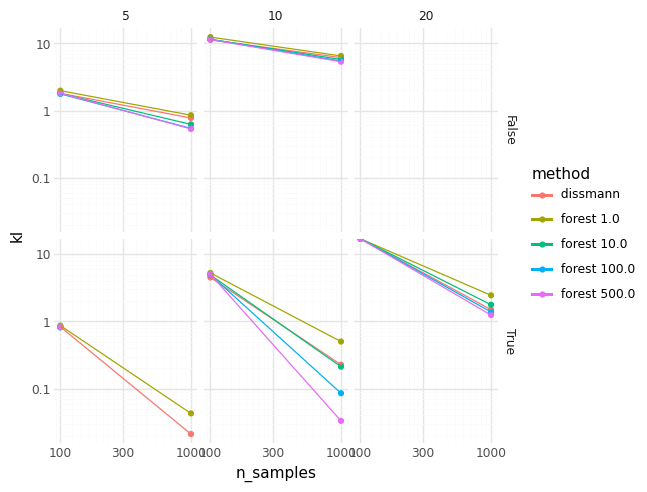

In [98]:
# Plot the average KL divergence of the max forest to the true copula
# exclude NAs from mean computation
p = (
  p9.ggplot(
    df_long.dropna(subset=["kl"])
    .drop(columns=["seed", "n_vines"])
    .groupby(["dim", "decreasing", "n_samples", "method"])["kl"]
    .mean()
    .reset_index(),
    p9.aes(x="n_samples", y="kl", color="method"),
  )
  + p9.geom_point()
  + p9.geom_line()
  + p9.scale_x_log10()
  + p9.scale_y_log10()
  + p9.facet_grid("decreasing", "dim")
  + p9.theme_minimal()
)
p.show()

In [ ]:
from math import comb, factorial


def number_of_vines(d, truncated=False):
  if not truncated:
    # https://filelist.tudelft.nl/EWI/Over%20de%20faculteit/Afdelingen/Applied%20Mathematics/Applied%20Probability/Risk/Download/Counting%20Vines.pdf
    # https://repository.tudelft.nl/file/File_c0a2d934-c15f-413b-b5f9-d6592b74c644?preview=1
    return (factorial(d) / 2) * 2 ** comb(d - 2, 2)
    # return comb(d, 2) * factorial(d - 2) * 2 ** comb(d - 2, 2)
  else:
    # https://proceedings.mlr.press/v89/chang19a/chang19a.pdf
    # considering all levels
    return (factorial(d) / 2) * 2 ** ((d - 3) * (d - 2))


{
  d: {
    "vines": number_of_vines(d, False),
    "truncvines": number_of_vines(d, True),
  }
  for d in range(3, 9)
}